<a href="https://colab.research.google.com/github/clau-tc/Cuidados/blob/master/analisis_slep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importación, exploración y modificación de data

# Instalación de librerias

Se importan librerías para aprovechar funcionalidades ya construidas, ahorrando tiempo y facilitando el desarrollo de soluciones más robustas y eficientes.

Más adelante se importan librerías base de Python para verificar la existencia de librerías afin al análisis de dataframes. Si no existen en el sistema, se instalan.

Para ello, se crea un diccionario con el nombre de todas las librerías que se necesitan para el análisis de datos.

Luego se crea un ciclo for para recorrer clave y valor en cada items del diccionario creado. Si no existe, se instala el paquete. Si existe, se anuncia que está instalado.

Para instalar una por una se usa: !pip install nombre_libreria


**Nota:**
El diccionario es un tipo de datos en Python que se puede entender a partir de los diccionarios físicos (por ej.: RAE) con los conceptos de clave y valor, siendo la clave un concepto en RAE y el valor su significado.



In [ ]:
import importlib
import subprocess
import sys

# Diccionario de librerías a verificar
librerias = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "openpyxl": "openpyxl",
    "unidecode": "unidecode",
    "sklearn": "scikit-learn"
}

for modulo, paquete in librerias.items():

    if importlib.util.find_spec(modulo) is None:
        print(f"Instalando {paquete}...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", paquete]
        )
    else:
        print(f"✓ {modulo} ya está instalada")

print("\nValidación finalizada")


✓ pandas ya está instalada
✓ numpy ya está instalada
✓ matplotlib ya está instalada
✓ openpyxl ya está instalada
✓ unidecode ya está instalada
✓ sklearn ya está instalada

Validación finalizada


In [ ]:
# Librerías para análisis de datos

import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode
import numpy as np

# Importar datos

La importación de datos es el primer paso de cualquier proyecto con análisis estadístico, ya que permite cargar información desde distintas fuentes para transformarla en conocimiento útil para la toma de decisiones.

En Python, Pandas facilita la importación de datos desde múltiples formatos como Excel, CSV y bases de datos.

Luego de una importación es importante revisar: estructra df, valores nulos o vacíos, tipo de variables, entre otras características para tomar decisiones sobre la limpieza.


In [ ]:
# Importar datos
# Link de descarga del Excel
url_excel = 'https://www.dropbox.com/scl/fi/yjvxyq5rqh9w5tj409o17/planilla_sueldos_SLEP.xlsx?rlkey=syjth05o4y5ljhym7i3036vzp&st=ugw8tcst&dl=1'

# Cargar archivo Excel
slep = pd.read_excel(url_excel)

# df = pd.read_excel('df.xlsx', sheet_name=0) sheet_name = "Hoja1"

# Mostrar primeras 5 filas, esta función sirve para observar a grandes rasgos como está estruturado el df: nombre de columnas, ¿se ven Na? (si no se ven, significa que en las primeras 5 filas no hay, no que no existan en todo el df), tipos de variables (int, float, str)
slep.head()

,Profesor,Horas Contratadas,Sueldo Base SLEP,Experiencia,Hijos,Antiguedad,Unnamed,Bono Movilización,Bono Hijos,Bono Antiguedad
0,FERNANDA VASCONCELLOS,40,0,Baja,2,7,NaN,31545,0,0
1,FRANCISCA GAJARDO,44,0,Alta,3,15,NaN,43135,0,0
2,SOFÍA LARRAZABAL,42,0,Alta,3,2,NaN,35090,0,0
3,PAZ AZÓCAR,41,0,Alta,4,10,NaN,33000,0,0
4,JOSÉ MAIRA,42,0,Baja,0,11,NaN,47690,0,0


In [ ]:
# Mostrar dimensiones df (número de filas y columnas)
slep.shape

# otra forma: len(slep) para filas y len(slep.columns) para columnas

(20, 10)

In [ ]:
# Revisemos nombre de columnas (o variables de df): es importante para evitar errores en la programación evitar nombres con mayúsculas, espacios entre palabras, tildes, diaresis, virgulillas
slep.columns

Index(['Profesor', 'Horas Contratadas', 'Sueldo Base SLEP', 'Experiencia',
       'Hijos', 'Antiguedad', 'Unnamed', 'Bono Movilización', 'Bono Hijos',
       'Bono Antiguedad'],
      dtype='object')

In [ ]:
# Otras funciones para explorar df

# Información general: con esta función se puede observar cuánta memoria usa, tipo de variables y si hay Na en el df (es más confiable para analizarlo a nivel gral de df)
slep.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Profesor           20 non-null     object 
 1   Horas Contratadas  20 non-null     int64  
 2   Sueldo Base SLEP   20 non-null     int64  
 3   Experiencia        20 non-null     object 
 4   Hijos              20 non-null     int64  
 5   Antiguedad         20 non-null     int64  
 6   Unnamed            0 non-null      float64
 7   Bono Movilización  20 non-null     int64  
 8   Bono Hijos         20 non-null     int64  
 9   Bono Antiguedad    20 non-null     int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 1.7+ KB


In [ ]:
# Otras funciones para explorar df

# Nombres de columnas
slep.columns


Index(['Profesor', 'Horas Contratadas', 'Sueldo Base SLEP', 'Experiencia',
       'Hijos', 'Antiguedad', 'Unnamed', 'Bono Movilización', 'Bono Hijos',
       'Bono Antiguedad'],
      dtype='object')

In [ ]:
# Otras funciones para explorar df

# Tipos de datos
slep.dtypes


,0
Profesor,object
Horas Contratadas,int64
Sueldo Base SLEP,int64
Experiencia,object
Hijos,int64
Antiguedad,int64
Unnamed,float64
Bono Movilización,int64
Bono Hijos,int64
Bono Antiguedad,int64


In [ ]:
# Otras funciones para explorar df

# Últimos registros
slep.tail()


,Profesor,Horas Contratadas,Sueldo Base SLEP,Experiencia,Hijos,Antiguedad,Unnamed,Bono Movilización,Bono Hijos,Bono Antiguedad
15,EDUARDO ARBOLEDA,44,0,Baja,4,6,NaN,35472,0,0
16,ISABEL NEIRA,42,0,Alta,4,9,NaN,43770,0,0
17,MIGUEL CONTRERAS,42,0,Alta,1,6,NaN,40801,0,0
18,SANTIAGO YÉVENES,43,0,Baja,0,12,NaN,40985,0,0
19,ISABEL RUIZ,40,0,Alta,0,7,NaN,34219,0,0


In [ ]:
# Otras funciones para explorar df

# Crea un resumen estadístico para cada una de las variables del df (frecuencia, media, desv. estándar, min, max, cuartiles)
slep.describe()


,Horas Contratadas,Sueldo Base SLEP,Hijos,Antiguedad,Unnamed,Bono Movilización,Bono Hijos,Bono Antiguedad
count,20.000000,20.0,20.000000,20.000000,0.0,20.000000,20.0,20.0
mean,42.200000,0.0,2.350000,7.950000,NaN,38522.000000,0.0,0.0
std,1.472556,0.0,1.663066,3.677456,NaN,5767.001447,0.0,0.0
min,40.000000,0.0,0.000000,2.000000,NaN,28925.000000,0.0,0.0
25%,41.000000,0.0,0.750000,5.750000,NaN,33914.250000,0.0,0.0
50%,42.000000,0.0,3.000000,8.000000,NaN,39567.500000,0.0,0.0
75%,44.000000,0.0,4.000000,11.000000,NaN,42601.750000,0.0,0.0
max,44.000000,0.0,4.000000,15.000000,NaN,49245.000000,0.0,0.0


In [ ]:
# Otras funciones para explorar df

# Muestra aleatoria
slep.sample(5)

,Profesor,Horas Contratadas,Sueldo Base SLEP,Experiencia,Hijos,Antiguedad,Unnamed,Bono Movilización,Bono Hijos,Bono Antiguedad
13,RAÙL MORALES,40,0,Alta,0,10,NaN,35772,0,0
3,PAZ AZÓCAR,41,0,Alta,4,10,NaN,33000,0,0
0,FERNANDA VASCONCELLOS,40,0,Baja,2,7,NaN,31545,0,0
15,EDUARDO ARBOLEDA,44,0,Baja,4,6,NaN,35472,0,0
17,MIGUEL CONTRERAS,42,0,Alta,1,6,NaN,40801,0,0


In [ ]:
# Resumen estadístico
resumen_estadistico = slep.describe(include='all')
resumen_estadistico

,Profesor,Horas Contratadas,Sueldo Base SLEP,Experiencia,Hijos,Antiguedad,Unnamed,Bono Movilización,Bono Hijos,Bono Antiguedad
count,20,20.000000,20.0,20,20.000000,20.000000,0.0,20.000000,20.0,20.0
unique,20,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,FERNANDA VASCONCELLOS,NaN,NaN,Alta,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,13,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,42.200000,0.0,NaN,2.350000,7.950000,NaN,38522.000000,0.0,0.0
std,NaN,1.472556,0.0,NaN,1.663066,3.677456,NaN,5767.001447,0.0,0.0
min,NaN,40.000000,0.0,NaN,0.000000,2.000000,NaN,28925.000000,0.0,0.0
25%,NaN,41.000000,0.0,NaN,0.750000,5.750000,NaN,33914.250000,0.0,0.0
50%,NaN,42.000000,0.0,NaN,3.000000,8.000000,NaN,39567.500000,0.0,0.0
75%,NaN,44.000000,0.0,NaN,4.000000,11.000000,NaN,42601.750000,0.0,0.0


# Limpieza de datos

La limpieza de datos es el proceso de preparar una base de datos para su análisis, corrigiendo errores, eliminando inconsistencias y asegurando que la información sea confiable. Este paso es fundamental porque la calidad de los resultados depende directamente de la calidad de los datos.

Con Python, especialmente utilizando la librería Pandas, es posible realizar tareas como:

Eliminar valores nulos o faltantes (dropna()).
Reemplazar datos faltantes por valores adecuados (fillna()).
Eliminar registros duplicados (drop_duplicates()).
Corregir tipos de datos (convertir texto a números o fechas).
Estandarizar formatos de texto, fechas o categorías.
Detectar y tratar valores atípicos (outliers).

## Valores vacíos o nulos

Los valores vacíos (nulos o faltantes) pueden afectar la calidad del análisis y generar resultados incorrectos. Su tratamiento permite trabajar con información más confiable y consistente.

Principales razones:

Evitan errores en los cálculos: Algunas operaciones estadísticas o matemáticas pueden fallar o entregar resultados incorrectos cuando existen valores vacíos.
Mejoran la calidad del análisis: Los datos incompletos pueden distorsionar promedios, porcentajes y otras métricas.
Facilitan la visualización de datos: Gráficos y tablas suelen ser más claros cuando los datos faltantes han sido tratados adecuadamente.
Permiten crear modelos más precisos: Muchos algoritmos de análisis de datos y aprendizaje automático no aceptan valores nulos o reducen su rendimiento si estos existen.
Aumentan la consistencia de la base de datos: Una base limpia es más fácil de interpretar y mantener.

Importante: No siempre es necesario eliminar los valores vacíos. En algunos casos es mejor reemplazarlos por un valor representativo (como el promedio, la mediana o una categoría específica) para no perder información relevante. La decisión depende del contexto y de la cantidad de datos faltantes.

In [ ]:
# Revisar específicamente cuantos na hay por variable
#slep.isnull().sum()
slep.isna().sum()

# Otra forma, mismo fin: (slep == '').sum()

,0
Profesor,0
Horas Contratadas,0
Sueldo Base SLEP,0
Experiencia,0
Hijos,0
Antiguedad,0
Unnamed,20
Bono Movilización,0
Bono Hijos,0
Bono Antiguedad,0


In [ ]:
# Literal: Selecciona todas las filas del DataFrame slep que contengan al menos un valor nulo
slep[slep.isnull().any(axis=1)]

,Profesor,Horas Contratadas,Sueldo Base SLEP,Experiencia,Hijos,Antiguedad,Unnamed,Bono Movilización,Bono Hijos,Bono Antiguedad
0,FERNANDA VASCONCELLOS,40,0,Baja,2,7,NaN,31545,0,0
1,FRANCISCA GAJARDO,44,0,Alta,3,15,NaN,43135,0,0
2,SOFÍA LARRAZABAL,42,0,Alta,3,2,NaN,35090,0,0
3,PAZ AZÓCAR,41,0,Alta,4,10,NaN,33000,0,0
4,JOSÉ MAIRA,42,0,Baja,0,11,NaN,47690,0,0
5,SARA FUENTEALBA,41,0,Baja,3,5,NaN,32610,0,0
6,ALONSO SÁNCHEZ,43,0,Alta,1,12,NaN,42424,0,0
7,IGNACIO MARTÍNEZ,44,0,Alta,4,6,NaN,30742,0,0
8,LÍA BARRERA,41,0,Alta,4,2,NaN,49245,0,0
9,DIANA LACÁMARA,42,0,Baja,3,3,NaN,28925,0,0


In [ ]:
# dropna() por defecto elimina toda la fila si al menos una columna tiene un valor nulo (antes de usar esta función es recomendable analizar la estrutura del df con: df.isnull, df.isna, df.info )
df_limpio1 = slep.dropna()
# probar argumento de dropna: (how='all')
df_limpio1

,Profesor,Horas Contratadas,Sueldo Base SLEP,Experiencia,Hijos,Antiguedad,Unnamed,Bono Movilización,Bono Hijos,Bono Antiguedad


In [ ]:
# dropna(axis=1) con el argumento axis=1 refiere al análisis de columnas. si una columna tiene al menos una fila con na se elimina la columna.
# en el caso de este df este argumento es adecuado usarlo, porque todos los nas existentes estaban en una columna.
df_limpio2 = slep.dropna(axis=1) # eliminar columnas NA
df_limpio2

,Profesor,Horas Contratadas,Sueldo Base SLEP,Experiencia,Hijos,Antiguedad,Bono Movilización,Bono Hijos,Bono Antiguedad
0,FERNANDA VASCONCELLOS,40,0,Baja,2,7,31545,0,0
1,FRANCISCA GAJARDO,44,0,Alta,3,15,43135,0,0
2,SOFÍA LARRAZABAL,42,0,Alta,3,2,35090,0,0
3,PAZ AZÓCAR,41,0,Alta,4,10,33000,0,0
4,JOSÉ MAIRA,42,0,Baja,0,11,47690,0,0
5,SARA FUENTEALBA,41,0,Baja,3,5,32610,0,0
6,ALONSO SÁNCHEZ,43,0,Alta,1,12,42424,0,0
7,IGNACIO MARTÍNEZ,44,0,Alta,4,6,30742,0,0
8,LÍA BARRERA,41,0,Alta,4,2,49245,0,0
9,DIANA LACÁMARA,42,0,Baja,3,3,28925,0,0


In [ ]:
# print nos permite inmprimir o mostrar texto en consola
print("Dimensiones originales:", slep.shape)
print("Dimensiones limpias:", df_limpio2.shape)

Dimensiones originales: (20, 10)
Dimensiones limpias: (20, 9)


In [ ]:
# Revisar nombres de columnas
df_limpio2.columns

Index(['Profesor', 'Horas Contratadas', 'Sueldo Base SLEP', 'Experiencia',
       'Hijos', 'Antiguedad', 'Bono Movilización', 'Bono Hijos',
       'Bono Antiguedad'],
      dtype='object')

Buenas prácticas de Python (**snake_case**): consiste en escribir nombres compuestos uniendo palabras solo con letras minúsculas y separándolas con guiones bajos (ej. nombre_usuario).

## Dónde usar snake_case
De acuerdo con las convenciones de Python (PEP 8), esta estructura se debe aplicar específicamente a:


*   Variables: (ej. total_facturado, user_id).
*   Funciones: (ej. calcular_total()).
*   Métodos: (ej. obtener_datos()).Nombres de módulos o archivos: (ej. conexion_bd.py).

## Cuándo **no** usar snake_case
Para mantener un código estructurado, Python recomienda utilizar diferentes convenciones dependiendo del elemento:
*   Clases: Se debe utilizar PascalCase (la primera letra de cada palabra en mayúscula, sin guiones bajos, ej. UsuarioAdmin).
*   Constantes: Se acostumbra utilizar todo en mayúsculas con guiones bajos (ej. MAX_INTENTOS).


In [ ]:
# para normalizar el nombre de las columnas podemos usar una función. Las funciones permiten que el código sea más eficiente si tenemos que repetir acciones a lo largo de nuestro proyecto.
# Esta es la estrutura de una función en python:


def normalizar_columnas(df): # def: declara la función / normalizar_columnas: nombre de la función / (df) parámetro de entrada
    # código
    df.columns = (
        df.columns
          .str.strip()  # eliminar espacios principio y final
          .map(unidecode) # eliminar tildes/virgulillas/diaresis
          .str.lower() # dejar todas las palabras en minúsculas
          .str.replace(' ', '_', regex=False) # reemplazar espacio en blanco por _
          .str.replace(r'[^a-z0-9_]', '', regex=True) # regex: busca caracteres que no sean: minúsculas y números, remplaza por ''
          .str.replace(r'_+', '_', regex=True) # regex: busca guión bajo doble y remplaza por "_"
    )
    return df

# df = normalizar_columnas(df_limpio2)


In [ ]:
# En adelante hacemos paso a paso la limpieza de nombres de variable:

df_limpio2.columns = df_limpio2.columns.str.strip()
df_limpio2.columns

Index(['Profesor', 'Horas Contratadas', 'Sueldo Base SLEP', 'Experiencia',
       'Hijos', 'Antiguedad', 'Bono Movilización', 'Bono Hijos',
       'Bono Antiguedad'],
      dtype='object')

In [ ]:
df_limpio2.columns = df_limpio2.columns.map(unidecode)
df_limpio2.columns

# map permite aplicar una función a todos los elementos de df_limpio2.columns (una lista)

Index(['Profesor', 'Horas Contratadas', 'Sueldo Base SLEP', 'Experiencia',
       'Hijos', 'Antiguedad', 'Bono Movilizacion', 'Bono Hijos',
       'Bono Antiguedad'],
      dtype='object')

In [ ]:
df_limpio2.columns = df_limpio2.columns.str.lower()
df_limpio2.columns

Index(['profesor', 'horas contratadas', 'sueldo base slep', 'experiencia',
       'hijos', 'antiguedad', 'bono movilizacion', 'bono hijos',
       'bono antiguedad'],
      dtype='object')

In [ ]:
df_limpio2.columns = df_limpio2.columns.str.replace(" ", "_", regex=False)
df_limpio2.columns

Index(['profesor', 'horas_contratadas', 'sueldo_base_slep', 'experiencia',
       'hijos', 'antiguedad', 'bono_movilizacion', 'bono_hijos',
       'bono_antiguedad'],
      dtype='object')

# Modificación de dataframes

## Crear variables

La creación de variables permite transformar y enriquecer los datos originales para obtener información más útil y facilitar el análisis. Una variable creada puede resumir, clasificar o destacar características que no están disponibles directamente en la base de datos.

Principales beneficios:

* Facilita el análisis: Permite organizar la información de una manera más comprensible.
* Genera nuevos indicadores: A partir de datos existentes se pueden crear métricas más relevantes para el estudio.
* Ayuda a identificar patrones: Las variables derivadas pueden revelar relaciones o tendencias que no son evidentes en los datos originales.
* Mejora la visualización: Es más sencillo crear gráficos e informes utilizando categorías o indicadores específicos.
* Optimiza modelos predictivos: En análisis avanzados y aprendizaje automático, las variables creadas suelen mejorar la capacidad de predicción.

In [ ]:
# Calcular variables
# recordar que en Python se usa ',' para separación de miles y '.' para decimales
# Sueldo base
hora_slep = 21286 # esta es una variable aux para transformar una variable de df
type(hora_slep)

# ¿nueva variable?: ojo en este df ya se encontraba la variable solicitada tipo int

df_limpio2.loc[:, 'sueldo_base_slep'] = df_limpio2['horas_contratadas'] * hora_slep

# siguiente sintaxis hace lo mismo:
#df_limpio2["sueldo_base_slep"] = df_limpio2["horas_contratadas"] * hora_slep

df_limpio2["sueldo_base_slep"]

# loc e iloc son indexadores (propiedades especiales) de un DataFrame. Son recomendables por:
# 1) es más explícito: df.loc[:, "a"] vs df["a"]. Selecciona todas las filas (:) de la columna "a" vs selecciona columna "a".
# 2) selecciona filas y columnas al mismo tiempo:
# df.loc[filas, columnas]
# df.loc[df['ventas'] > 1000,['cliente', 'ventas']]: selecciona las ventas mayores de 1000 y muestra columnas cliente y venta
# versus solo corchetes df[df[filas]][[columnas]]
# df[df['ventas'] > 1000][['cliente', 'ventas']]
# 3) evitar warnings
# df_filtrado['bono'] = 1000 WARNING! vs df_filtrado.loc["bono"] = 1000
# .loc[] localizar por nombres
# .loc[:, "a"] todas las filas de la columna "a"
# .iloc[] localizar por indice

,sueldo_base_slep
0,851440
1,936584
2,894012
3,872726
4,894012
5,872726
6,915298
7,936584
8,872726
9,894012


In [ ]:
# Revisar nueva variable
# crosstab() construye una tabla de frecuencias cruzadas.
# ¿Cuántas veces aparece cada combinación entre sueldo_base_slep y horas_contratadas?
pd.crosstab(
    df_limpio2["sueldo_base_slep"],
    df_limpio2["horas_contratadas"]
)

horas_contratadas,40,41,42,43,44
sueldo_base_slep,,,,,
851440,3,0,0,0,0
872726,0,4,0,0,0
894012,0,0,5,0,0
915298,0,0,0,2,0
936584,0,0,0,0,6


In [ ]:
# Crear variables: bono por hijo
valor_uf = 39643.59
type(valor_uf)

df_limpio2.loc[:, 'bono_hijos'] = (df_limpio2['hijos'] * valor_uf).astype(float)

# .astype() es una forma de hacer consistente la nueva variable, ya que estamos multiplicando enteros con decimales

df_limpio2["bono_hijos"]

/tmp/ipykernel_1016/1308294735.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 79287.18 118930.77 118930.77 158574.36      0.   118930.77  39643.59
 158574.36 158574.36 118930.77 118930.77 158574.36      0.        0.
 158574.36 158574.36 158574.36  39643.59      0.        0.  ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_limpio2.loc[:, 'bono_hijos'] = (df_limpio2['hijos'] * valor_uf).astype(float)


,bono_hijos
0,79287.18
1,118930.77
2,118930.77
3,158574.36
4,0.00
5,118930.77
6,39643.59
7,158574.36
8,158574.36
9,118930.77


In [ ]:
# Revisar nueva variable
pd.crosstab(
    df_limpio2["bono_hijos"],
    df_limpio2["hijos"]
)

hijos,0,1,2,3,4
bono_hijos,,,,,
0.00,5,0,0,0,0
39643.59,0,2,0,0,0
79287.18,0,0,1,0,0
118930.77,0,0,0,5,0
158574.36,0,0,0,0,7


In [ ]:
# Crear variable: bono antiguedad
# 10% del sueldo base a 10 años o más
# 5% al resto

df_limpio2.loc[:, 'bono_antiguedad'] = np.where(
    df_limpio2['antiguedad'] > 9,
    df_limpio2['sueldo_base_slep'] * 0.10,
    df_limpio2['sueldo_base_slep'] * 0.05
).astype(float)


/tmp/ipykernel_1016/3717668728.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[42572.  93658.4 44700.6 87272.6 89401.2 43636.3 91529.8 46829.2 43636.3
 44700.6 93658.4 46829.2 87272.6 85144.  93658.4 46829.2 44700.6 44700.6
 91529.8 42572. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_limpio2.loc[:, 'bono_antiguedad'] = np.where(


In [ ]:
# Revisar nueva variable
pd.crosstab(
    df_limpio2["bono_antiguedad"],
    df_limpio2["antiguedad"]
)

antiguedad,2,3,4,5,6,7,9,10,11,12,15
bono_antiguedad,,,,,,,,,,,
42572.0,0,0,0,0,0,2,0,0,0,0,0
43636.3,1,0,0,1,0,0,0,0,0,0,0
44700.6,1,1,0,0,1,0,1,0,0,0,0
46829.2,0,0,1,0,2,0,0,0,0,0,0
85144.0,0,0,0,0,0,0,0,1,0,0,0
87272.6,0,0,0,0,0,0,0,1,1,0,0
89401.2,0,0,0,0,0,0,0,0,1,0,0
91529.8,0,0,0,0,0,0,0,0,0,2,0
93658.4,0,0,0,0,0,0,0,1,1,0,1


In [ ]:
df_limpio2.loc[:, 'sueldo_total'] = (
    df_limpio2['sueldo_base_slep']
    + df_limpio2['bono_movilizacion']
    + df_limpio2['bono_hijos']
    + df_limpio2['bono_antiguedad']
    + np.where(
        df_limpio2['experiencia'] == 'Alta',
        500000,
        200000
    )
)

In [ ]:
slep_filtrado = df_limpio2.loc[
    (df_limpio2['horas_contratadas'] > 42) &
    (df_limpio2['experiencia'] == 'Alta') &
    (df_limpio2['antiguedad'] > 10)
]
slep_filtrado

,profesor,horas_contratadas,sueldo_base_slep,experiencia,hijos,antiguedad,bono_movilizacion,bono_hijos,bono_antiguedad,sueldo_total
1,FRANCISCA GAJARDO,44,936584,Alta,3,15,43135,118930.77,93658.4,1692308.17
6,ALONSO SÁNCHEZ,43,915298,Alta,1,12,42424,39643.59,91529.8,1588895.39


# Visualización

La visualización de datos permite transformar grandes cantidades de información en gráficos e imágenes fáciles de interpretar. Esto ayuda a comprender los datos de manera más rápida y efectiva que observando tablas extensas.

Principales beneficios:

Facilita la comprensión de la información: Los gráficos permiten identificar tendencias y comportamientos de forma inmediata.
Ayuda a detectar patrones y anomalías: Es más sencillo encontrar relaciones, valores atípicos o cambios importantes en los datos.
Mejora la comunicación de resultados: Los hallazgos pueden ser explicados de manera clara a personas técnicas y no técnicas.
Apoya la toma de decisiones: Los gráficos permiten basar decisiones en evidencia visual y objetiva.
Hace más atractivo el análisis: La información visual suele ser más fácil de recordar y comprender que una tabla de números.

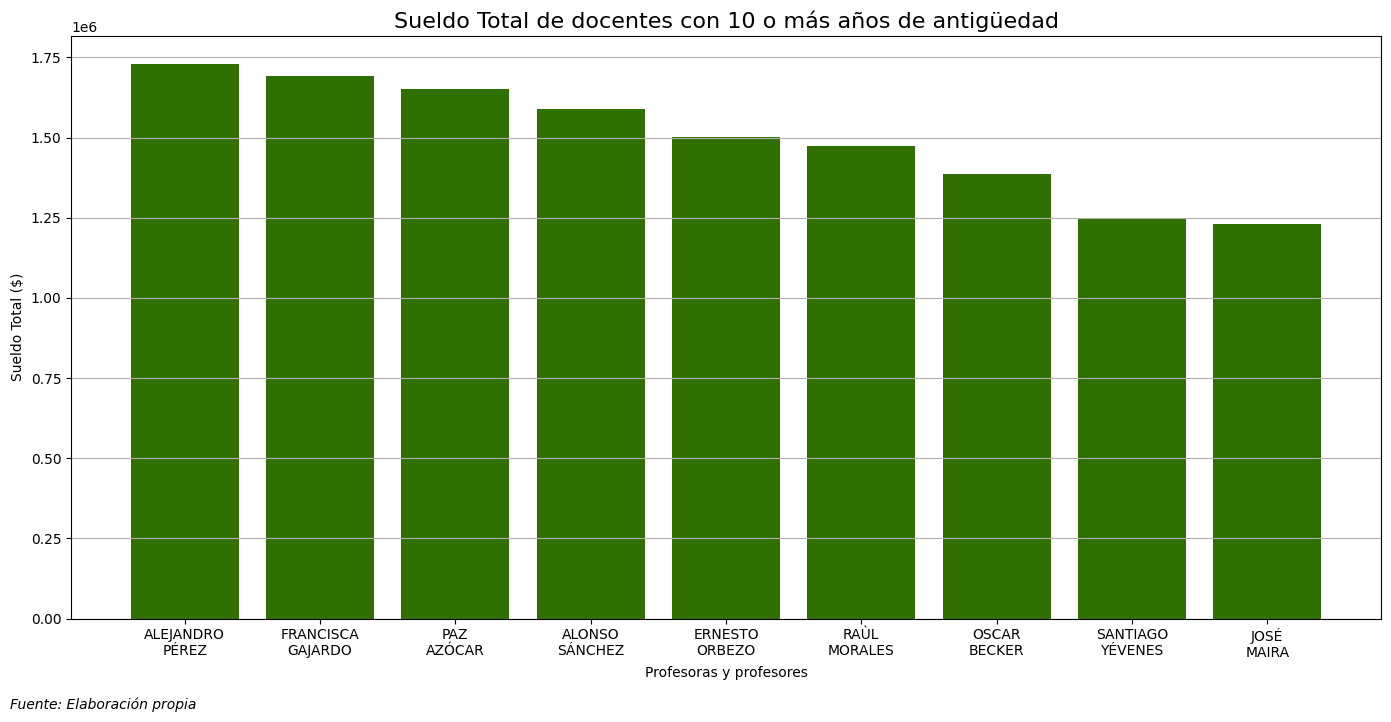

In [ ]:

# Filtrar
# estamos creando un df aux para usarlo en la visualización, selecciona los registros que cumplan con antiguedad mayor igual a 10
profesores_exp = (
    df_limpio2.loc[df_limpio2['antiguedad'] >= 10]
    .copy()
)

# Ordenar por sueldo
profesores_exp = profesores_exp.sort_values( # sort_values() permite ordenar df
    by='sueldo_total', # by permite seleccionar variable de referencia para ordenar
    ascending=False #ascending=False significa en orden descendente, y True lo contrario
)

# Crear nombres en dos líneas
nombres = profesores_exp['profesor'].str.replace(
    ' ',
    '\n',
    regex=False
)



# selecciono variable profesor y str. permite aplicar funciones de texto a una columna completa, en este caso:
# replace(busqueda, remplazo) busco espacios en blanco(' ') para remplazar por salto de línea (\n)


# Gráfico
plt.figure(figsize=(14, 7))
# con esta función (.figure) creo espacio para crear un gráfico, figsize=(14,7) define ancho y alto en pulgadas.

# Gráfico de barras
plt.bar(
    nombres,
    profesores_exp['sueldo_total'],
    color='#307001'
)
# .bar() grafico de barras
# primer parámetro: nombres eje x, segundo parámetro: sueldo eje y, tercer parámetro: color de barras
# gráfico de barras donde los nombres aparecen en el eje horizontal y los sueldos en el eje vertical."

# Título del gráfico
plt.title(
    'Sueldo Total de docentes con 10 o más años de antigüedad',
    fontsize=16
)

# etiquetas de ambos ejes
plt.xlabel('Profesoras y profesores')
plt.ylabel('Sueldo Total ($)')

# configuración de nombres que apareccen en eje x: Sin rotación
plt.xticks(rotation=0)

# agregar cuadrícula
plt.grid(axis='y')

# Ajusta automáticamente los márgenes. Evita que se superpongan elementos.
plt.tight_layout()

# agregar fuente
plt.figtext(              # agrega texto libre dentro de la figura
    0.01,                 # posición horizontal
    -0.02,                # posición vertical
    'Fuente: Elaboración propia',
    ha='left',            # Alineación izquierda.
    fontsize=10,          # tamaño de fuente
    style='italic'        # estilo fuente
)

# Mostrar gráfico
plt.show()

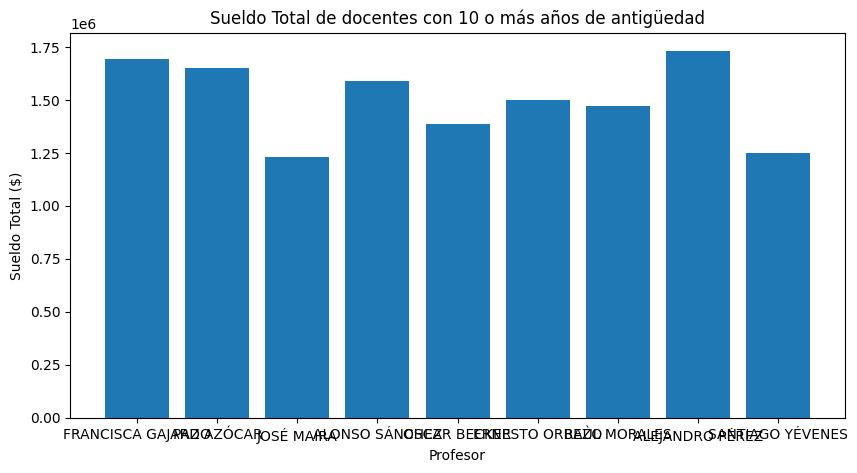

In [ ]:
# Alternativa para crear mismo gráfico más básico, para que evalues la pertinencia del código anterior.
# Filtrar profesores con antigüedad mayor o igual a 10 años
profesores_exp = df_limpio2.loc[
    df_limpio2['antiguedad'] >= 10
]

# Crear gráfico
plt.figure(figsize=(10,5))

plt.bar(
    profesores_exp['profesor'],
    profesores_exp['sueldo_total']
)

plt.title('Sueldo Total de docentes con 10 o más años de antigüedad')
plt.xlabel('Profesor')
plt.ylabel('Sueldo Total ($)')

plt.show()

In [ ]:
df_limpio2.columns